In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('param_sweep.csv')

In [3]:
PARAM_VALUES = {
    "int_reg_issue_width": list(range(1, 8+1)),
    "int_mult_div_issue_width": list(range(1, 8+1)),
    "fp_reg_issue_width": list(range(1, 8+1)),
    "fp_mult_div_issue_width": list(range(1, 8+1)),
    "read_port_issue_width": list(range(1, 8+1)),
    "rdwr_port_issue_width": list(range(1, 8+1)),
    # "simd_unit_issue_width": [1],
    "fetch_width": list(range(1, 12+1)),
    "decode_width": list(range(1, 12+1)),
    "rename_width": list(range(1, 12+1)),
    "wb_width": list(range(1, 12+1)),
    "commit_width": list(range(1, 12+1)),
    "rob_size": list(range(1, 1024+1)),
    "lq_entries": list(range(1, 256+1)),
    "sq_entries": list(range(1, 256+1)),
    "branch_predictor": [0, 1],
    "l1d_size": [16, 32, 64, 128, 256],
    "l1i_size": [16, 32, 64, 128, 256],
    "l2_size": [512, 1024, 2048, 4096],
    "max_icache_fills": list(range(1, 32+1)),
    "stride_prefetcher_degree": [0, 4],
}

In [4]:
df["branch_predictor"] = df["branch_predictor"].map({"local": 0, "tage": 1})
df["l1d_size"] = df["l1d_size"].map({"16KiB": 16, "32KiB": 32, "64KiB": 64, "128KiB": 128, "256KiB": 256})
df["l1i_size"] = df["l1i_size"].map({"16KiB": 16, "32KiB": 32, "64KiB": 64, "128KiB": 128, "256KiB": 256})
df["l2_size"] = df["l2_size"].map({"512KiB": 512, "1MiB": 1024, "2MiB": 2048, "4MiB": 4096})


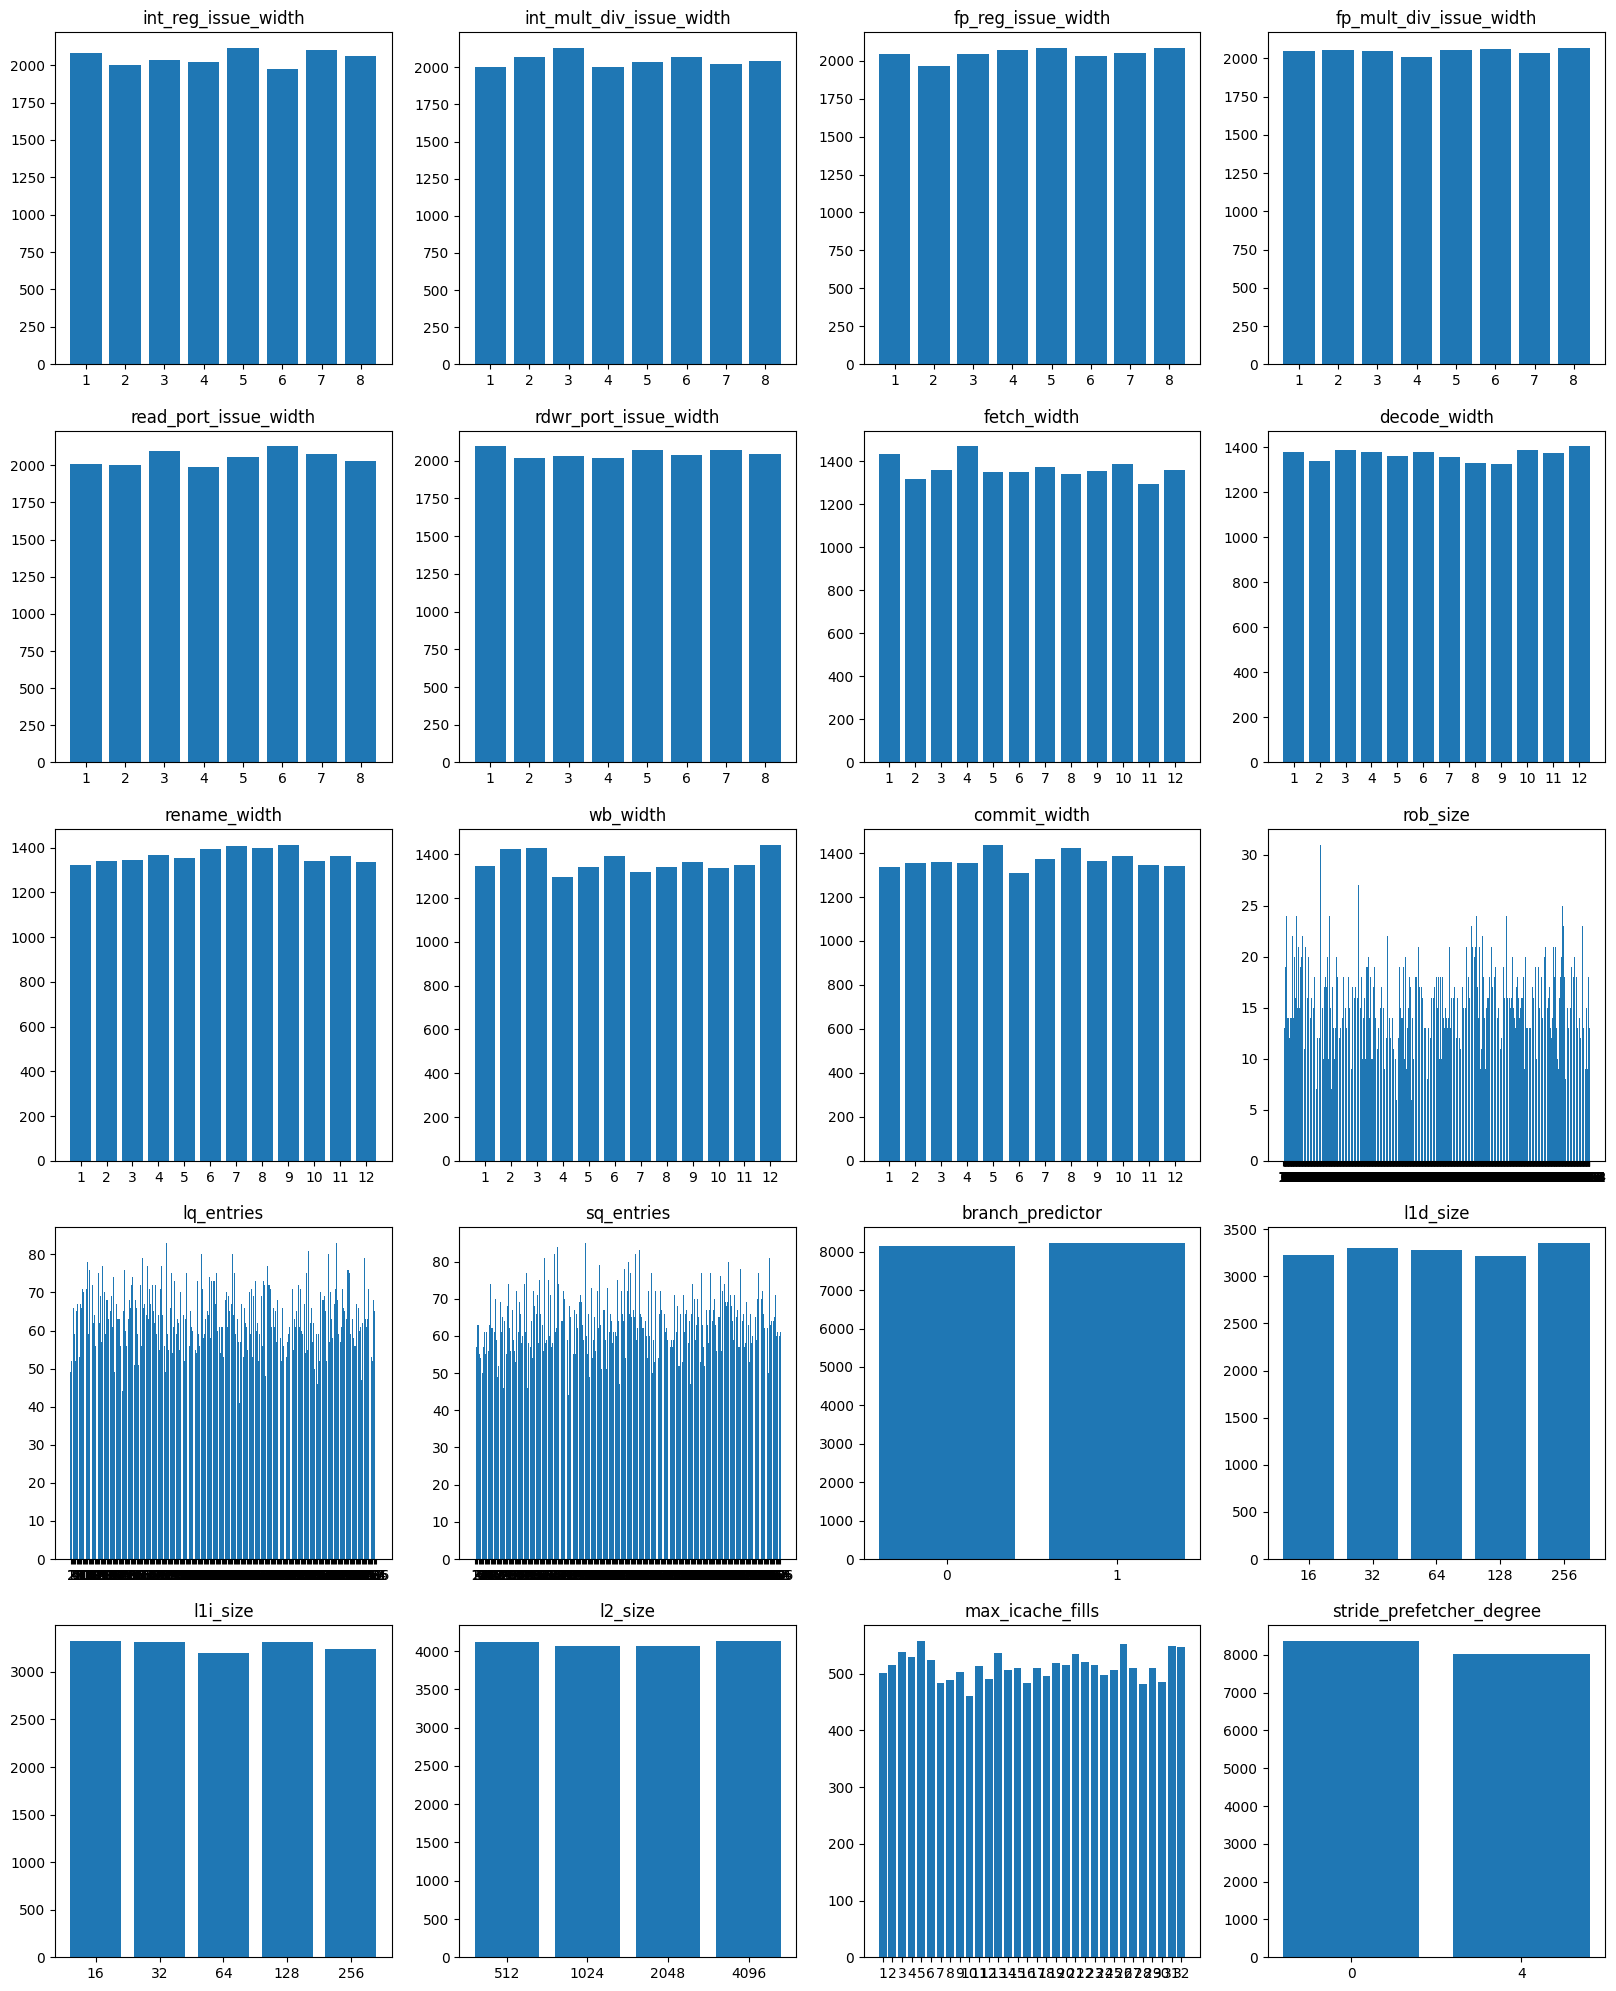

In [6]:
# Create a figure with subplots for each parameter
fig, axes = plt.subplots((len(PARAM_VALUES)+3)//4, 4, figsize=(20, 25))
for i, param in enumerate(PARAM_VALUES):
    ax = axes[i//4, i%4]
    values = df[param].value_counts().sort_index()
    positions = range(len(values))
    counts = values.values
    ax.bar(positions, counts)
    ax.set_xticks(positions)
    ax.set_xticklabels(values.index)
    ax.set_title(param)
plt.show()